# Price Prediction By Regression 

In [3]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data = fetch_california_housing()
data_housing = pd.DataFrame(data.data , columns = data.feature_names)
data_housing["price"] = data.target 
data_housing

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [30]:
data_housing.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
correlation = data_housing.corr()
correlation

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


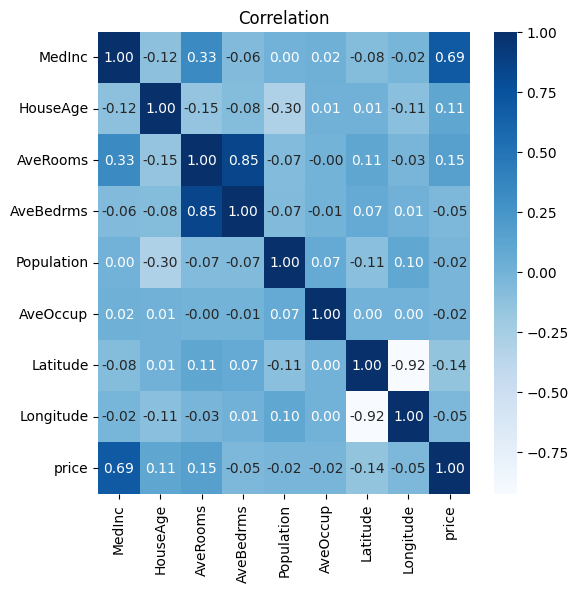

In [9]:
plt.figure(figsize=(6,6))
sns.heatmap(correlation,annot = True, cmap="Blues" , fmt=".2f")
plt.title("Correlation")
plt.show()


In [10]:
X = data_housing.drop(columns="price",axis = 1)
Y = data_housing["price"]

#### Splitting the data

In [14]:
x_train , x_test , y_train , y_test = train_test_split(X,Y,test_size=0.3 ,random_state=2)
print(x_train.shape,x_test.shape)

(14448, 8) (6192, 8)


#### modeling 

In [17]:
model = Pipeline([("scaling",StandardScaler())
                  ,("XGBR",XGBRegressor())])
model.fit(x_train,y_train)
x_prediction_train = model.predict(x_train)


In [22]:
print("R_squared for x_train prediction : ",metrics.r2_score(x_prediction_train,y_train))
print("absolute mean error for x_train prediction : ",metrics.mean_absolute_error(x_prediction_train,y_train))

R_squared for x_train prediction :  0.9425522464386936
absolute mean error for x_train prediction :  0.1853034281894106


In [24]:
x_prediction_test = model.predict(x_test)
print("R_squared for x_train prediction : ",metrics.r2_score(x_prediction_test,y_test))
print("absolute mean error for x_train prediction : ",metrics.mean_absolute_error(x_prediction_test,y_test))


R_squared for x_train prediction :  0.8047279130760685
absolute mean error for x_train prediction :  0.31150292865712204


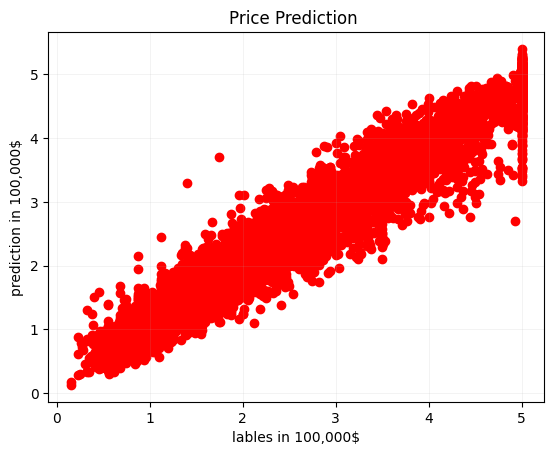

In [26]:
plt.scatter(y_train,x_prediction_train,color = "red")
#plt.scatter(y_test,x_prediction_test,color = "blue")
plt.title("Price Prediction ")
plt.xlabel("lables in 100,000$")
plt.ylabel("prediction in 100,000$")
plt.xticks(np.arange(0,6,1))
plt.yticks(np.arange(0,6,1))
plt.grid(alpha = 0.2, linewidth=0.5)
plt.show()